<a href="https://colab.research.google.com/github/outscore6052/rfm_analysis/blob/main/rfm_code_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("rfm_raw.csv")
df.head()


,CustomerKey,Amount,Date,InvoNum
0,A1067,836.0,2018/04/02,AP1803827
1,A1129,836.0,2018/04/03,AP1808235
2,A1133,836.0,2018/04/04,AP1807305
3,A0464,836.0,2018/04/05,AP1806145
4,A0383,836.0,2018/04/05,AP1803092


In [3]:
# Ensure 'Date' is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Define a reference date for Recency (e.g., max date in dataset + 1 day, or today's date)
reference_date = df['Date'].max() + pd.Timedelta(days=1)

# Group by CustomerKey and aggregate
rfm_df = df.groupby('CustomerKey').agg(
    Customer=('CustomerKey', 'first'),                     # Customer: Keeps the CustomerKey
    F=('InvoNum', 'count'),                              # F: Count of Invoice Numbers (Frequency)
    M=('Amount', 'sum'),                                 # M: Sum of Amount (Monetary)
    R=('Date', lambda x: (reference_date - x.max()).days)  # R: Difference between reference date and MAX Date (Recency)
).reset_index(drop=True)

# Display the resulting DataFrame
print(rfm_df)

    Customer   F         M   R
0      A0350  25  51238.12  10
1      A0351   6  17890.31  17
2      A0352  14  46424.05  15
3      A0353  14  27607.70  25
4      A0354   6   9973.92  32
..       ...  ..       ...  ..
727    A1413  23  52738.80  11
728    A1415  20  53019.50  18
729    A1416  24  49938.39   5
730    A1419  22  64257.87  51
731    A1420  14  25054.19  86

[732 rows x 4 columns]


In [ ]:
rfm_df.to_csv("rfm_data.csv",index=False)

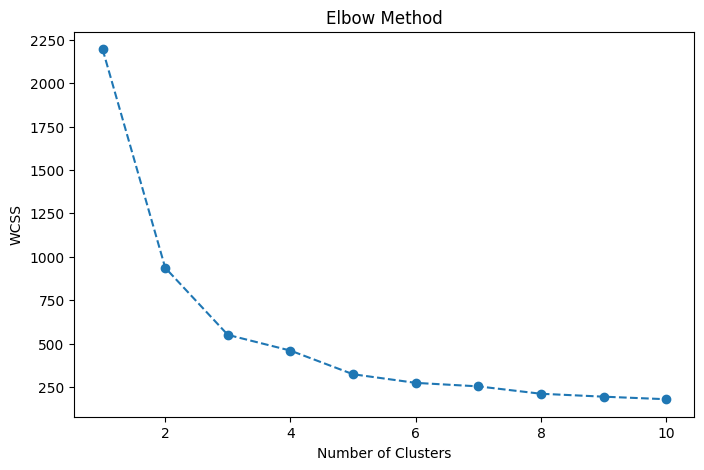

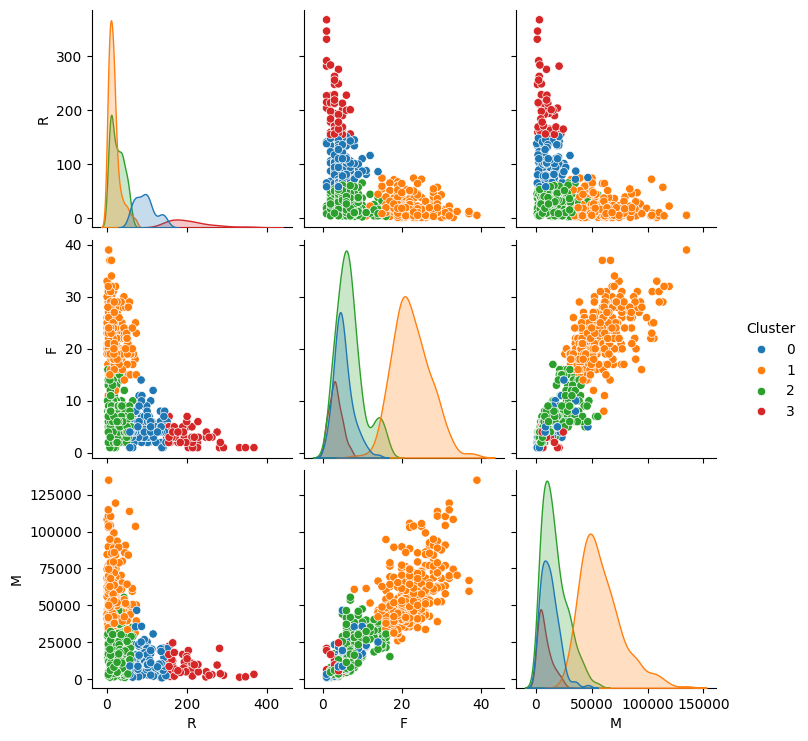

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

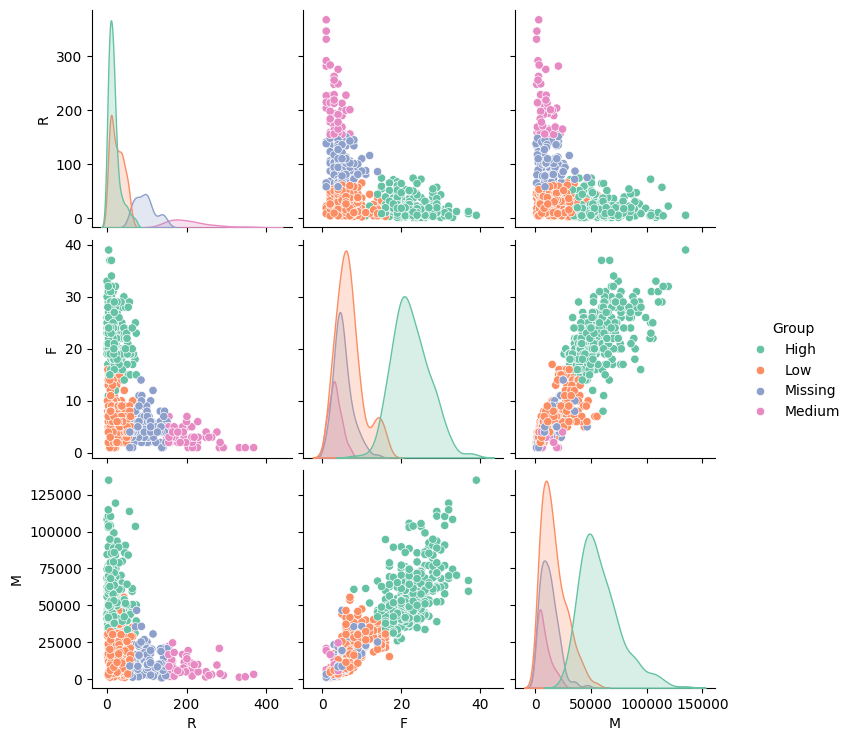

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# 1. Load rfm_data.csv.
df = pd.read_csv('rfm_data.csv')

# 2. Perform normalization on df and name it nrfm.
scaler = StandardScaler()
# We normalize only the numeric R, F, M features
rfm_features = df[['R', 'F', 'M']]
nrfm = pd.DataFrame(scaler.fit_transform(rfm_features), columns=['R', 'F', 'M'])

# 3. Plot an Elbow Chart according to nrfm, help determine optimal number of clusters for running K-means.
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(nrfm)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# 4. Perform K-means clustering using nrfm, with 4 clusters.
kmeans_model = KMeans(n_clusters=4, init='k-means++', random_state=42)
cluster_labels = kmeans_model.fit_predict(nrfm)

# 5. Add the "Cluster" label back to the original data set df.
df['Cluster'] = cluster_labels

# 6. Create a Pair Plot using the R,F,M column from df data, group the data by Cluster label.
sns.pairplot(df, vars=['R', 'F', 'M'], hue='Cluster', palette='tab10')
plt.show()

# 7. Add a new column to df with the header Group, where the values correspond to Cluster: 0>Missing, 1>High, 2>Low, 3>Medium.
cluster_mapping = {
    0: 'Missing',
    1: 'High',
    2: 'Low',
    3: 'Medium'
}
df['Group'] = df['Cluster'].map(cluster_mapping)

# 8. Plot the R,F,M values from the df dataset as a pairwise scatter plot, grouped by the Group label.
pairplot_fig = sns.pairplot(df, vars=['R', 'F', 'M'], hue='Group', palette='Set2')

# 9. Download this image as a transparent background image with the filename "rfm_pairplot.png".
pairplot_fig.savefig('rfm_pairplot.png', transparent=True)
files.download('rfm_pairplot.png')

# 10. Download the df in CSV format and save it as "rfm_result.csv".
df.to_csv('rfm_result.csv', index=False)
files.download('rfm_result.csv')